# Week 1 - Inspiring Visualizations
This notebook contains some visualizations that can be quickly created using Python. The goal is to provide you with ideas and examples of how to visualize data effectively. The visualizations are based on real-world datasets and demonstrate various techniques and libraries available in Python for data visualization.

The notebook is intended only for teaching in the course Explainable AI and Visualization at Leuphana University Lüneburg and may not be used for any other purposes, especially not distributed or published in any form. The code is provided as-is, without any warranty or guarantee of correctness. The authors are not responsible for any errors or omissions in the code or the data used in this notebook.
Moltzen, April 09, 2026
## Population Density Map
*This section is based on the following tutorial: https://medium.com/data-science/creating-beautiful-population-density-maps-with-python-fcdd84035e06
Full credit to the author: Adam Symington (2022) at PythonMaps*

In [1]:
# import all relevant libraries
import rasterio
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap

In [2]:
# Import geographical data from the GHS-POP dataset with rasterio
# Since the file is very large, please download and unpack the dataset to the data folder using this link: https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_POP_GLOBE_R2023A/GHS_POP_E2030_GLOBE_R2023A_4326_30ss/V1-0/GHS_POP_E2030_GLOBE_R2023A_4326_30ss_V1_0.zip
tif_file = rasterio.open('data/GHS_POP_E2030_GLOBE_R2023A_4326_30ss_V1_0/GHS_POP_E2030_GLOBE_R2023A_4326_30ss_V1_0.tif')
ghs_data = tif_file.read()

In [3]:
# Print some metadata
print("Tiff Boundary", tif_file.bounds)
print("Tiff CRS", tif_file.crs)
print("Data shape", ghs_data.shape)
print("Max value", np.amax(ghs_data))
print("Min value", np.amin(ghs_data))

Tiff Boundary BoundingBox(left=-180.00791593130032, bottom=-89.10041610517152, right=180.00874930942342, top=89.0995831776456)
Tiff CRS EPSG:4326
Data shape (1, 21384, 43202)
Max value 394367.2599414062
Min value 0.0


In [4]:
# Create a custom colormap for the population density
our_cmap = matplotlib.colormaps.get_cmap('hot_r') # Get the continuous 'hot_r' colormap
new_colors = our_cmap(np.linspace(0, 1, 394)) # Sample 394 discrete colors from it
new_cmp = ListedColormap(new_colors) # Create a new discrete colormap

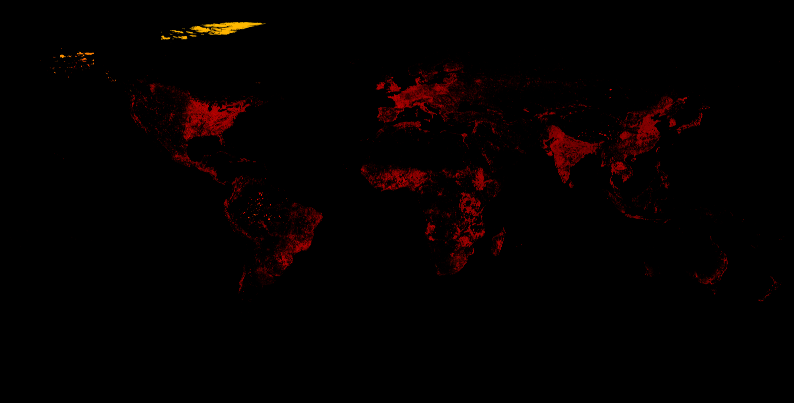

In [5]:
# Create a new figure and axis including resolution (adjust figure size and resolution if it takes too long to render / can't be shown on your machine; runtimes of several minutes are normal.)
fig, ax = plt.subplots(figsize=(10,5), dpi=100)
ax.imshow(ghs_data[0], norm=colors.LogNorm(), cmap=new_cmp) # Create the final plot
ax.axis('off') # Remove axis to make it look cleaner
fig.savefig("output/population_density_global.png", dpi=100) # optionally save the figure
plt.show() # Show the figure

## Climate Stripes
Recreating the iconic climate stripes visualization. The original visualization was created by Highwoord and Hawkins (2017) at the University of Reading. The idea behind the climate stripes is to represent temperature anomalies over time using a simple layout and visually striking color gradient.


In [6]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [7]:
# Load data
temperature_data = pd.read_csv("data/GlobalLandTemperaturesByCountry.csv", parse_dates=['dt'])
global_temperature = pd.read_csv("data/GlobalTemperatures.csv", parse_dates=['dt'])

In [8]:
# Let's first look at some basic information about the data
print("Temperature data shape:", temperature_data.shape)
print("Temperature data columns:", temperature_data.columns)
print("Temperature data data ypes \n", temperature_data.dtypes)
print("Unique countries:", temperature_data['Country'].nunique())
print("Temperature data first rows:\n", temperature_data.head())

Temperature data shape: (577462, 4)
Temperature data columns: Index(['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'Country'], dtype='str')
Temperature data data ypes 
 dt                               datetime64[us]
AverageTemperature                      float64
AverageTemperatureUncertainty           float64
Country                                     str
dtype: object
Unique countries: 243
Temperature data first rows:
           dt  AverageTemperature  AverageTemperatureUncertainty Country
0 1743-11-01               4.384                          2.294   Åland
1 1743-12-01                 NaN                            NaN   Åland
2 1744-01-01                 NaN                            NaN   Åland
3 1744-02-01                 NaN                            NaN   Åland
4 1744-03-01                 NaN                            NaN   Åland


In [9]:
temperature_data

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland
...,...,...,...,...
577457,2013-05-01,19.059,1.022,Zimbabwe
577458,2013-06-01,17.613,0.473,Zimbabwe
577459,2013-07-01,17.000,0.453,Zimbabwe
577460,2013-08-01,19.759,0.717,Zimbabwe


In [10]:
# Filter and preprocess country-level temperature data
excluded_countries = [
    "Africa", "Asia", "Baker Island", "Europe", "North America", "Saint Martin",
    "Palmyra Atoll", "Virgin Islands", "South America", "Oceania", "Kingman Reef"
]

temperature_data = temperature_data[
    (temperature_data['dt'] >= pd.to_datetime("1750-01-01")) &
    (~temperature_data['Country'].isin(excluded_countries))
].copy()

temperature_data['year'] = temperature_data['dt'].dt.year
temperature_data['month'] = temperature_data['dt'].dt.month
temperature_data.dropna(inplace=True)

In [11]:
# Filter for Italy
italy = temperature_data[temperature_data['Country'] == 'Italy']

# Preprocess global data
global_temperature['year'] = global_temperature['dt'].dt.year
global_temperature['month'] = global_temperature['dt'].dt.month
global_temperature = global_temperature[['dt', 'year', 'month', 'LandAverageTemperature']].dropna()

# Calculate annual means
annual_means = global_temperature.groupby('year')['LandAverageTemperature'].mean().reset_index()
italy_annual_means = italy.groupby('year')['AverageTemperature'].mean().reset_index()

# Align years
end_year = min(italy_annual_means['year'].max(), annual_means['year'].max())

# Calculate baseline mean (1971–2000)
baseline_mean = annual_means[
    (annual_means['year'] >= 1971) & (annual_means['year'] <= 2000)
]['LandAverageTemperature'].mean()

annual_anomalies = annual_means[
    (annual_means['year'] >= 1870) & (annual_means['year'] <= end_year)
].copy()
annual_anomalies['TemperatureAnomaly'] = annual_anomalies['LandAverageTemperature'] - baseline_mean
annual_anomalies

,year,LandAverageTemperature,TemperatureAnomaly
120,1870,8.201333,-0.723700
121,1871,8.115083,-0.809950
122,1872,8.193833,-0.731200
123,1873,8.351083,-0.573950
124,1874,8.433500,-0.491533
...,...,...,...
259,2009,9.505250,0.580217
260,2010,9.703083,0.778050
261,2011,9.516000,0.590967
262,2012,9.507333,0.582300


In [12]:
# Do the same for Italy again
italy_baseline_mean = italy_annual_means[
    (italy_annual_means['year'] >= 1971) & (italy_annual_means['year'] <= 2000)
]['AverageTemperature'].mean()

italy_annual_anomalies = italy_annual_means[
    (italy_annual_means['year'] >= 1870) & (italy_annual_means['year'] <= end_year)
].copy()
italy_annual_anomalies['TemperatureAnomaly'] = italy_annual_anomalies['AverageTemperature'] - italy_baseline_mean

In [13]:
# Define the function to create a stripes plot
def make_stripes(df, label, color_range):
    # Create a new figure using plotly graph_objects
    fig = go.Figure()

    # Create a bar trace for the temperature anomalies
    fig.add_trace(go.Bar(
        x=df['year'], # x-axis values (years)
        y=[1] * len(df), # y-axis values (constant height for stripes), 1 for each year
        marker=dict( # use a custom color scale for the bars, colored by temperature anomaly using the marker attribute
            color=df['TemperatureAnomaly'],
            cmin=color_range[0],
            cmax=color_range[1],
            colorscale=[[0, '#02509D'], [0.5, 'white'], [1, '#CC1117']],  # custom blue to red
            line=dict(width=0)
        ),
        hovertemplate=label + " %{x}: %{marker.color:.2f}°C<extra></extra>",
        showlegend=False
    ))
    return fig

In [14]:
# Get consistent color range
cmin = min(annual_anomalies['TemperatureAnomaly'].min(), italy_annual_anomalies['TemperatureAnomaly'].min())
cmax = max(annual_anomalies['TemperatureAnomaly'].max(), italy_annual_anomalies['TemperatureAnomaly'].max())
color_range = [cmin, cmax]
print(color_range)

[np.float64(-1.2804361111111078), np.float64(1.1410638888888922)]


In [15]:
# Create the stripes plot for both datasets
fig_world = make_stripes(annual_anomalies, "World", color_range)
fig_italy = make_stripes(italy_annual_anomalies, "Italy", color_range)

In [16]:
# Combine plots
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.02,
    horizontal_spacing=0.0
)

# Add bar traces to each row
for trace in fig_world.data:
    fig.add_trace(trace, row=1, col=1)
for trace in fig_italy.data:
    fig.add_trace(trace, row=2, col=1)

# Assign y-axis titles and styling
fig.update_yaxes(
    title_text="World", row=1, col=1,
    title_standoff=0,
    title_font=dict(size=28),
    showticklabels=False,
    showgrid=False
)
fig.update_yaxes(
    title_text="Italy", row=2, col=1,
    title_standoff=0,
    title_font=dict(size=28),
    showticklabels=False,
    showgrid=False
)
# Update x-axis styling
fig.update_xaxes(tickfont=dict(size=24))

# Update overall figure layout
fig.update_layout(
    height=600,
    width=1400,
    title_text="Climate Stripes: Temperature Anomalies over Time for the World and Italy",
    title_font=dict(size=34),
    showlegend=False,
    hoverlabel=dict(bgcolor='white'),
    margin=dict(l=40, r=20, t=80, b=20),
    bargap=0,
    xaxis=dict(showgrid=False, tickmode='linear', tick0=1870, dtick=20)
)

fig.show()

Now, please go ahead and play around with the data by yourselves, and make yourselves familiar with the libraries used in this notebook. You can also try to create your own visualizations using the data provided in the `data` folder. If you have any questions or need help, feel free to ask!

As always, please do not distribute or publish any of the contents.

## Radar chart

In [17]:
import pandas as pd

# Load the CSV into a DataFrame; data from https://huggingface.co/spaces/open-llm-leaderboard/comparator; don't rely too much on the exact values!
df = pd.read_csv("data/llm_results.csv")
df

,Unnamed: 0,deepseek-ai/DeepSeek-R1-Distill-Llama-70B,mistralai/Mistral-Large-Instruct-2411,meta-llama/Llama-3.3-70B-Instruct,google/gemma-2-27b-it
0,bbh.acc_norm,0.562229,0.670023,0.691547,0.642250
1,bbh_boolean_expressions.acc_norm,0.868000,0.912000,0.916000,0.872000
2,bbh_causal_judgement.acc_norm,0.518717,0.556150,0.679144,0.609626
3,bbh_date_understanding.acc_norm,0.656000,0.784000,0.704000,0.656000
4,bbh_disambiguation_qa.acc_norm,0.396000,0.752000,0.664000,0.736000
5,bbh_formal_fallacies.acc_norm,0.652000,0.696000,0.820000,0.628000
6,bbh_geometric_shapes.acc_norm,0.556000,0.432000,0.352000,0.456000
7,bbh_hyperbaton.acc_norm,0.560000,0.844000,0.708000,0.788000
8,bbh_logical_deduction_five_objects.acc_norm,0.504000,0.676000,0.656000,0.592000
9,bbh_logical_deduction_seven_objects.acc_norm,0.496000,0.644000,0.624000,0.568000


In [18]:
# Define benchmark groups and their associated row labels
benchmark_groups = {
    "BBH": df[df.iloc[:, 0].str.startswith("bbh")],
    "GPQA": df[df.iloc[:, 0].str.startswith("gpqa")],
    "IFEval": df[df.iloc[:, 0].str.startswith("ifeval")],
    "MATH": df[df.iloc[:, 0].str.startswith("math")],
    "MMLU-Pro": df[df.iloc[:, 0].str.startswith("mmlu_pro")],
    "MuSR": df[df.iloc[:, 0].str.startswith("musr")],
}
# Compute the mean for each benchmark group and each model
summary_df = pd.DataFrame({
    benchmark: group.iloc[:, 1:].mean()  # exclude first column with task names
    for benchmark, group in benchmark_groups.items()
}).T  # Transpose to have models as columns and tasks as rows

summary_df.reset_index(inplace=True)
summary_df.rename(columns={"index": "Benchmark"}, inplace=True)

summary_df

,Benchmark,deepseek-ai/DeepSeek-R1-Distill-Llama-70B,mistralai/Mistral-Large-Instruct-2411,meta-llama/Llama-3.3-70B-Instruct,google/gemma-2-27b-it
0,BBH,0.563446,0.674479,0.691916,0.645023
1,GPQA,0.268857,0.430122,0.323101,0.377818
2,IFEval,0.438140,0.857119,0.905091,0.808271
3,MATH,0.296056,0.474844,0.465823,0.218089
4,MMLU-Pro,0.474817,0.556184,0.533162,0.445146
5,MuSR,0.433799,0.453595,0.445705,0.403005


In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Colorblind-friendly palette (Color Universal Design / Okabe-Ito)
colorblind_palette = [
    "#E69F00", "#009E73", "#F0E442",
    "#0072B2", "#D55E00", "#CC79A7"
]

# Setup
labels = summary_df["Benchmark"]
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles.append(angles[0])

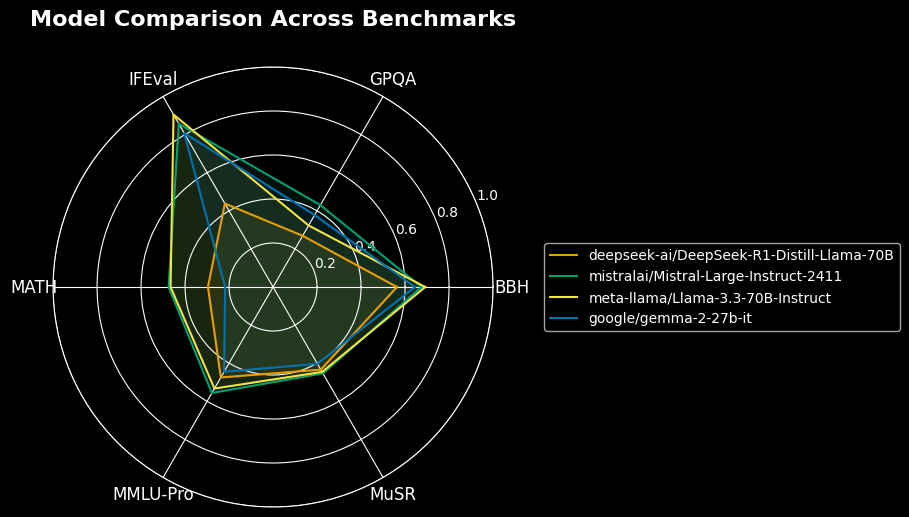

In [20]:
# Initialize plot
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))

# Plot each model
model_names = summary_df.columns[1:]
for idx, model in enumerate(model_names):
    values = summary_df[model].tolist()
    values += values[:1]
    ax.plot(angles, values, label=model, color=colorblind_palette[idx])
    ax.fill(angles, values, color=colorblind_palette[idx], alpha=0.1)

# Format axes
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=10)
ax.set_ylim(0, 1)

# Move legend to the side
ax.legend(loc="center left", bbox_to_anchor=(1.1, 0.5), fontsize=10)

# Title
plt.title("Model Comparison Across Benchmarks", fontsize=16, fontweight='bold', pad=30, loc="center")
plt.tight_layout()
plt.show()

In [21]:
import plotly.graph_objects as go

fig = go.Figure()

# Add a trace for each model with color from palette
for idx, model in enumerate(summary_df.columns[1:]):
    fig.add_trace(go.Scatterpolar(
        r=summary_df[model],
        theta=summary_df["Benchmark"],
        fill='toself',
        name=model,
        line=dict(color=colorblind_palette[idx % len(colorblind_palette)])
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 1])
    ),
    title="Model Comparison Across Benchmarks (Plotly)",
    showlegend=True,
    width=800,
    height=600,
    font=dict(
        size=12
    )
)

fig.show()

## Hausaufgabe

Suchen Sie bis zur nächsten Übung eine Visualisierung quantiativer Daten heraus, die Sie informativ und visuell ansprechend finden. Die Visualisierung kann aus einem wissenschaftlichen Artikel oder Buch, Nachrichtenportal oder ähnlichem stammen. Geben Sie unbedingt die Quelle mit an.